### LIBRARY
Melakukan proses import library yang digunakan dalam pengolahan citra. Library numpy dimanfaatkan untuk memproses matriks pada gambar, matplotlib digunakan untuk menampilkan visualisasi data maupun citra, sedangkan opencv berfungsi dalam proses pengolahan gambar serta pengenalan pola.

In [303]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## MEMBACA, MENAMPILKAN, DAN PEMBERIAN NAMA PADA GAMBAR

Membaca citra Bunga, Langit, Meledak, dan Windut menggunakan cv2.imread dengan paramater lokasi file dalam folder Assets. menggunakan plt.imshow untuk menampilkan gambar dengan mengunci color pada warna abu.

(450, 800)


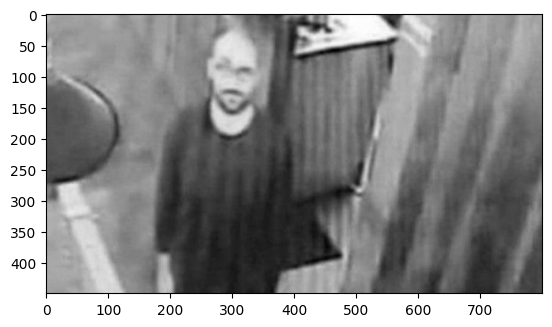

In [304]:
orang = cv2.imread('backup.jpg')
orangAbu = cv2.cvtColor(orang, cv2.COLOR_BGR2GRAY)
plt.imshow(orangAbu, cmap='gray')
plt.axis()
print(orangAbu.shape)



## Sliding Window (Filter mean, median, modus)

In [305]:
def filter(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape
    # ukuran padding / padding size
    pad = size // 2
    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':
            # filter rata-rata / mean filter
            area = size * size
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus mean manual / manual mean formula
                    total_sum = np.sum(region)
                    canvas[i, j] = total_sum // area
                    
        case 'median':
            # filter median / median filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus median manual / manual median formula
                    # urutkan pixel dalam region dan ambil nilai tengahnya
                    sorted_pixels = np.sort(region.ravel())
                    canvas[i, j] = sorted_pixels[(size * size) // 2]
                    
        case 'modus':
            # filter modus / mode filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # ratakan array / flatten array
                    values = region.ravel()
                    # hitung kemunculan / count occurrences
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    # cari nilai terbanyak / find mode value
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    # simpan hasil / save result
                    canvas[i, j] = mode_val
                    
    # kembalikan gambar / return image
    return canvas

## Fungsi Konvolusi

In [306]:
def convolution(img, kernel):
    # 1. Dimensi gambar dan kernel
    height, width = img.shape
    k_size = kernel.shape[0]
    pad = k_size // 2
    
    # 2. Tambahkan padding agar ukuran output sama dengan input
    padded_img = np.pad(img, pad, mode='edge')
    
    # 3. Siapkan kanvas kosong (menggunakan float untuk akurasi perhitungan)
    output = np.zeros_like(img, dtype=np.float32)
    
    # 4. Proses Konvolusi
    for i in range(height):
        for j in range(width):
            # Ambil area piksel seukuran kernel
            region = padded_img[i : i + k_size, j : j + k_size]
            
            # Operasi matematika: Kali elemen-per-elemen lalu jumlahkan
            # Rumus: G[i,j] = sum(region * kernel)
            output[i, j] = np.sum(region * kernel)
            
    # 5. Clipping (memastikan nilai tetap di range 0-255)
    return np.clip(output, 0, 255).astype(np.uint8)

In [307]:
# Cara panggil / how to call
orangMean3 = filter(orangAbu, 3, 'mean')
orangMean9 = filter(orangAbu, 9, 'mean')
orangMedian3 = filter(orangAbu, 3, 'median')
orangMedian9 = filter(orangAbu, 9, 'median')
orangModus3 = filter(orangAbu, 3, 'modus')
orangModus9 = filter(orangAbu, 9, 'modus')



## Kernel Perbaikan Citra

In [308]:
# Kernel rata-rata 3x3 (Box Blur)
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

# Kernel Sharpening yang menonjolkan titik pusat
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])



## Kernel Sobel

In [309]:
# kernel sobel sumbu x / x-axis sobel kernel
sobelX = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
], dtype=np.float32) #

# kernel sobel sumbu y / y-axis sobel kernel
sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32) #

## Kernel Prewitt

In [310]:
# kernel prewitt sumbu x / x-axis prewitt kernel
prewittX = np.array([
    [-1,  0,  1],
    [-1,  0,  1],
    [-1,  0,  1]
], dtype=np.float32) #

# kernel prewitt sumbu y / y-axis prewitt kernel
prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32) #

## Kernel Roberts

In [311]:
# kernel roberts sumbu x / x-axis roberts kernel
robertsX = np.array([
    [1,  0],
    [0, -1]
], dtype=np.float32)

# kernel roberts sumbu y / y-axis roberts kernel
robertsY = np.array([
    [0,  1],
    [-1, 0]
], dtype=np.float32)

In [312]:
orangSmooth = convolution(orangAbu, kernelSmoothing)
orangSharp = convolution(orangAbu, kernelSharpening)
orangSmoothSharp = convolution(orangSmooth, kernelSharpening)

In [313]:
orangMean3 = filter(orangAbu, 3, 'mean')
orangMedian3 = filter(orangAbu, 3, 'median')
orangModus3 = filter(orangAbu, 3, 'modus')


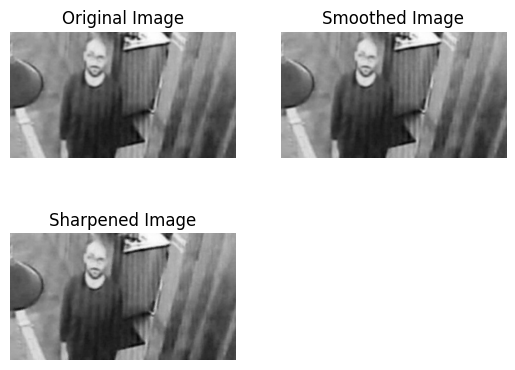

In [314]:
plt.subplot(2,2,1)
plt.imshow(orangMean3, cmap = 'gray')
plt.title('Mean')
plt.axis('off')
plt.subplot(2,2,2)
plt.imshow(orangMedian3, cmap = 'gray')
plt.title('Median')
plt.axis('off')
plt.subplot(2,2,3)
plt.imshow(orangModus3, cmap = 'gray')
plt.title('Modus')
plt.axis('off')


plt.show()

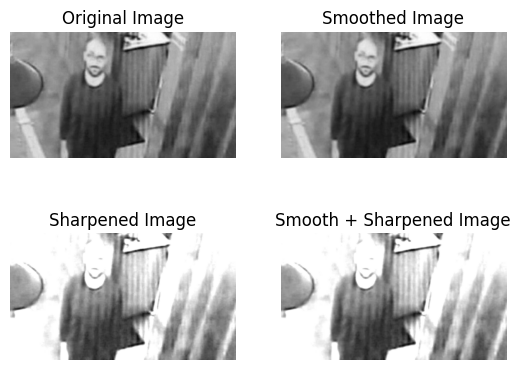

In [315]:
plt.subplot(2,2,1)
plt.imshow(orangAbu, cmap = 'gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(2,2,2)
plt.imshow(orangSmooth, cmap = 'gray')
plt.title('Smoothed Image')
plt.axis('off')
plt.subplot(2,2,3)
plt.imshow(orangSharp, cmap = 'gray')
plt.title('Sharpened Image')
plt.axis('off')
plt.subplot(2,2,4)
plt.imshow(orangSmoothSharp, cmap = 'gray')
plt.title('Smooth + Sharpened Image')
plt.axis('off')

plt.show()

Perbedaan pada ketiga gambar tersebut adalah pada citra smoothing citra akan terlihat lebih lembut dan halus, sedangkan pada citra sharpering kontras citra akan meningkat dan mempertegas detil pada citra. saat smooting dan sharpering digabungkan maka citra akan terlihat lebih lembut dan memiliki kontras tinggi.

## Fungsi Edge Detection

In [316]:
def edge(img, kernelx, kernely):
    # konvolusi sumbu x / x-axis convolution
    # Menggunakan fungsi convolution yang telah dibuat sebelumnya
    gx = convolution(img, kernelx)
    
    # konvolusi sumbu y / y-axis convolution
    gy = convolution(img, kernely)
    
    # kanvas kosong / empty canvas
    # Menggunakan float32 untuk menghindari overflow saat penjumlahan
    canvas = np.zeros_like(img, dtype=np.float32)
    
    # gabung gradien absolut / combine absolute gradients
    # Menghitung magnitudo tepi dengan menjumlahkan nilai absolut gx dan gy
    canvas = np.abs(gx) + np.abs(gy)
    
    # normalisasi ke 0-255 / normalize to 0-255
    # Memastikan kontras tepi terlihat jelas dalam rentang standar citra
    if np.max(canvas) != 0:
        canvas = canvas * 255.0 / np.max(canvas)
    
    # batas nilai dan konversi / clip values and convert
    # Memastikan tidak ada nilai di luar 0-255 dan mengubah kembali ke uint8
    return np.clip(canvas, 0, 255).astype(np.uint8)


In [317]:
# orangTepian_sobel = np.sqrt(
#     np.square(sobelX.astype(np.float32)) +
#     np.square(sobelY.astype(np.float32))
# )

# orangTepian_prewitt = np.sqrt(
#     np.square(prewittX.astype(np.float32)) +
#     np.square(prewittY.astype(np.float32))
# )

# orangTepian_roberts = np.sqrt(
#     np.square(robertsX.astype(np.float32)) +
#     np.square(robertsY.astype(np.float32))
# )

# orangTepian_sobel = np.clip(orangTepian_sobel, 0, 255)
# orangTepian_sobel = orangTepian_sobel.astype(np.uint8)

# orangTepian_prewitt = np.clip(orangTepian_prewitt, 0, 255)
# orangTepian_prewitt = orangTepian_prewitt.astype(np.uint8)

# orangTepian_roberts = np.clip(orangTepian_roberts, 0, 255)
# orangTepian_roberts = orangTepian_roberts.astype(np.uint8)


In [318]:
orangTepian_sobel = edge(orangAbu, sobelX, sobelY)
orangTepian_prewitt = edge(orangAbu, prewittX, prewittY)
orangTepian_roberts = edge(orangAbu, robertsX, robertsY)

In [319]:
def fungsi_jumlah(citra_1, citra_2): 
    return citra_1 + citra_2 

In [320]:
prewittXsobel = fungsi_jumlah(orangTepian_sobel, orangTepian_prewitt)
prewittXroberts = fungsi_jumlah(orangTepian_prewitt, orangTepian_roberts)
sobelXroberts = fungsi_jumlah(orangTepian_sobel, orangTepian_roberts)

prewittXsobelXroberts = fungsi_jumlah(prewittXsobel, orangTepian_roberts)



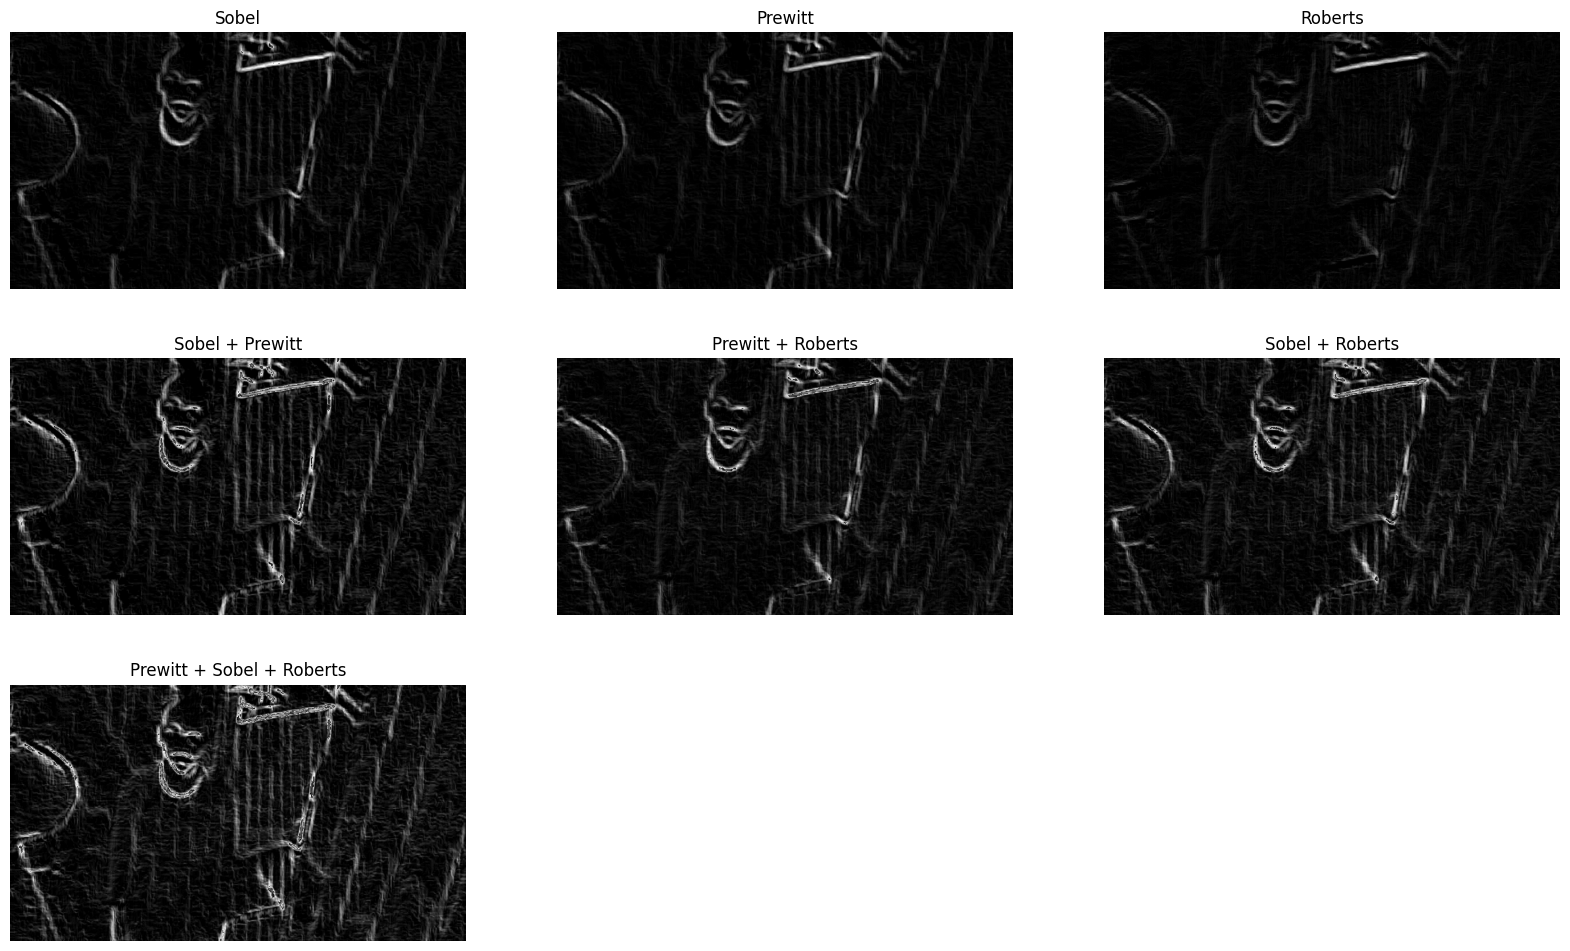

In [321]:
plt.figure(figsize=(20, 12))
plt.subplot(3,3,1)
plt.imshow(orangTepian_sobel, cmap = 'gray')
plt.title('Sobel')
plt.axis('off')
plt.subplot(3,3,2)
plt.imshow(orangTepian_prewitt, cmap = 'gray')
plt.title('Prewitt')
plt.axis('off')
plt.subplot(3,3,3)
plt.imshow(orangTepian_roberts, cmap = 'gray')
plt.title('Roberts')
plt.axis('off')
plt.subplot(3,3,4)
plt.imshow(prewittXsobel, cmap = 'gray')
plt.title('Sobel + Prewitt')
plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(prewittXroberts, cmap = 'gray')
plt.title('Prewitt + Roberts')
plt.axis('off')
plt.subplot(3,3,6)
plt.imshow(sobelXroberts, cmap = 'gray')
plt.title('Sobel + Roberts')
plt.axis('off')
plt.subplot(3,3,7)
plt.imshow(prewittXsobelXroberts, cmap = 'gray')
plt.title('Prewitt + Sobel + Roberts')
plt.axis('off')


plt.show()

1. Operator Sobel digunakan  untuk  mendeteksi  garis  tepi  (edge)  pada  gambar  dengan menyoroti perubahan warna atau kontras yang tajam secara horizontal dan vertikal, dan memberikan efek halus dan sedikit noise.

2. Operator Prewitt mirip seperti sobel tetapi tanpa penghalusan pada titik sengah dan sensitif terhadap noise.

3. Operator Roberts untuk mendeteksi garis tepi dengan menghitung 
perbedaan  kontras  secara  diagonal, tetapi filter ini paling rentang terhadap noise.

In [322]:
def treshold_tepi(img, treshold):
    return (img > treshold).astype(np.uint8) * 255


In [323]:
orang_tres10 = treshold_tepi(prewittXsobelXroberts, 10)
orang_tres20 = treshold_tepi(prewittXsobelXroberts, 20)
orang_tres30 = treshold_tepi(prewittXsobelXroberts, 30)
orang_tres40 = treshold_tepi(prewittXsobelXroberts, 40)
orang_tres50 = treshold_tepi(prewittXsobelXroberts, 50)
orang_tres60 = treshold_tepi(prewittXsobelXroberts, 60)

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

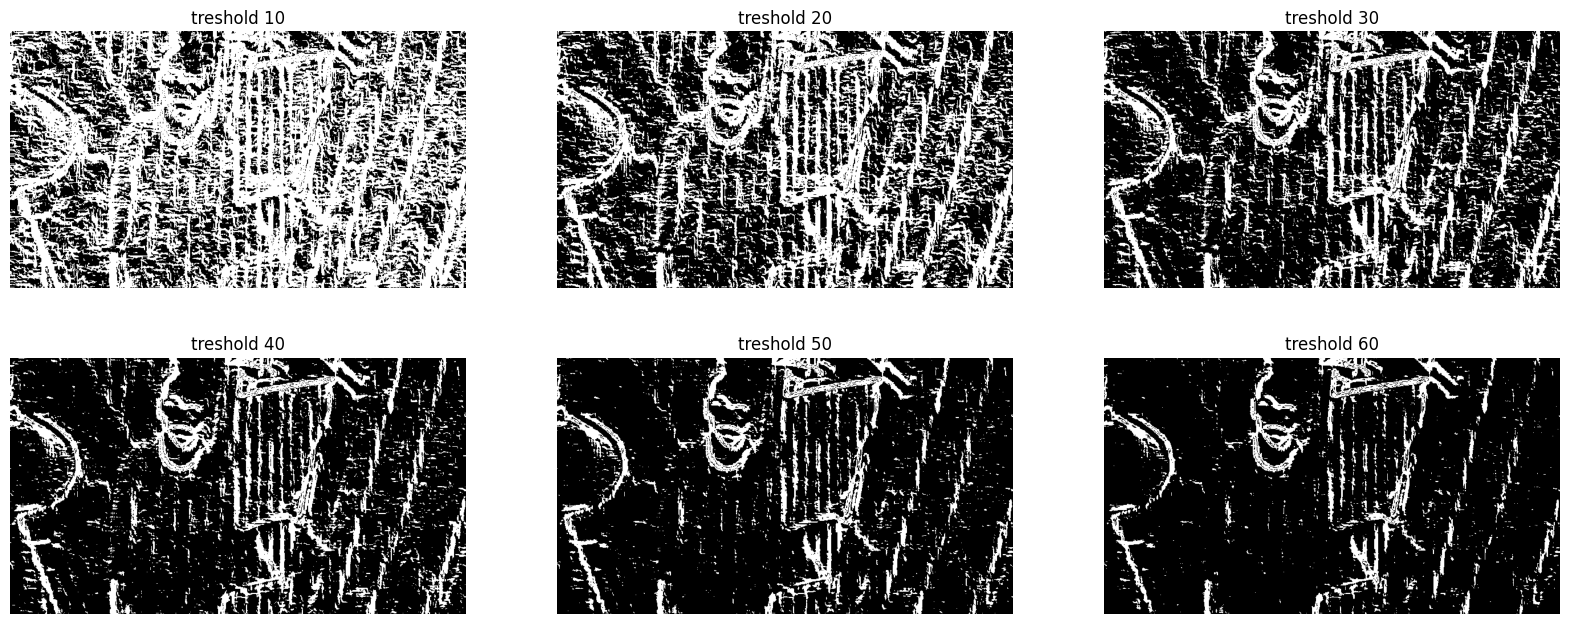

In [324]:
plt.figure(figsize=(20, 12))

plt.subplot(3,3,1)
plt.imshow(orang_tres10, cmap = 'gray')
plt.title('treshold 10')
plt.axis('off')
plt.subplot(3,3,2)
plt.imshow(orang_tres20, cmap = 'gray')
plt.title('treshold 20')
plt.axis('off')
plt.subplot(3,3,3)
plt.imshow(orang_tres30, cmap = 'gray')
plt.title('treshold 30')
plt.axis('off')
plt.subplot(3,3,4)
plt.imshow(orang_tres40, cmap = 'gray')
plt.title('treshold 40')
plt.axis('off')
plt.subplot(3,3,5)
plt.imshow(orang_tres50, cmap = 'gray')
plt.title('treshold 50')
plt.axis('off')
plt.subplot(3,3,6)
plt.imshow(orang_tres60, cmap = 'gray')
plt.title('treshold 60')
plt.axis('off')

Pada citra tersebut penggunaan dari tresholding adalah mengurangi noise pada citra. pada treshold rendah terlihat noise dan garis tepi masih terlihat dan banyak, sedangkan pada tresholding tinggi noise dan garis tepi semakin sedikit. tresholding yang paling bagus digunakan yaitu tresholding tinggi karena mengurangi noise dna membuat citra lebih jelas. 

# PAS FOTO

(788, 978)


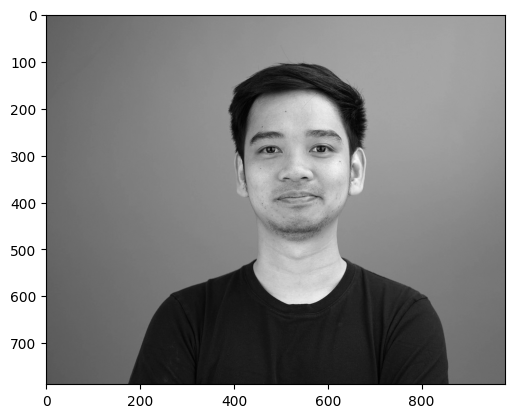

In [325]:
david = cv2.imread('david.jpg')
davidAbu = cv2.cvtColor(david, cv2.COLOR_BGR2GRAY)
plt.imshow(davidAbu, cmap='gray')
plt.axis()
print(davidAbu.shape)



(788, 978)


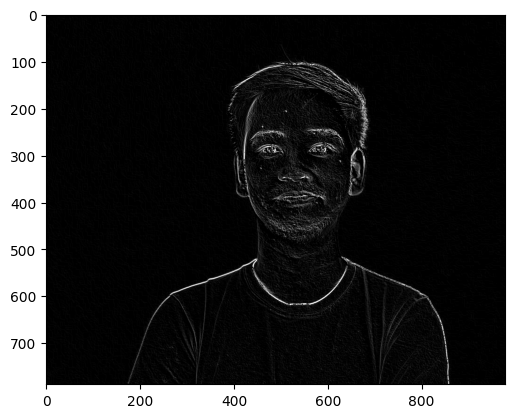

In [326]:
david_Sobel = edge(davidAbu, sobelX, sobelY)

plt.imshow(david_Sobel, cmap='gray')
plt.axis()
print(david_Sobel.shape)



In [327]:
def copy_citra(citra):
    h, w = citra.shape
    hasil = np.zeros((h, w), dtype=citra.dtype)

    for i in range(h):
        for j in range(w):
            hasil[i][j] = citra[i][j]

    return hasil

(788, 978)


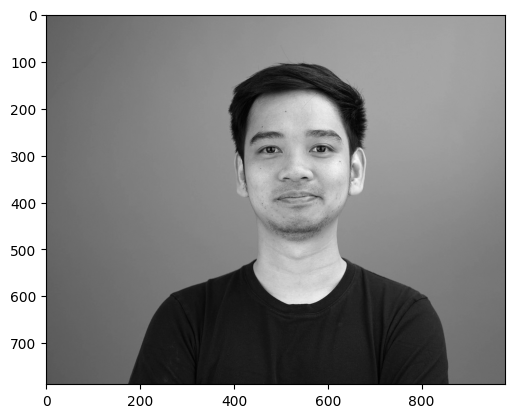

In [328]:
hasil = copy_citra(davidAbu)

plt.imshow(hasil, cmap='gray')
plt.axis()
print(hasil.shape)